In [68]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns




In [10]:
files_A = ["0", "3", "10", "13", "14", "17", "22", "24", "25", "26", "38",
           "40", "42", "45", "51", "68", "69", "71", "72", "73", "84", "92"]
path_base_A = os.path.join("data", "Wind Farm A", "datasets")

files_B = ["2", "7", "19", "21", "23", "27", "34", "52", "53", "74", "77",
           "82", "83", "86", "87"]
path_base_B = os.path.join("data", "Wind Farm B", "datasets")


In [11]:
def get_csv(path):
    return pd.read_csv(path, delimiter=";", parse_dates=["time_stamp"])

In [61]:
class Summary:
    def __init__(self, name, path_base, output_dir):
        self.name = name
        self.file = os.path.join(path_base, name + ".csv")
        self.output_path = os.path.join("data", "summary", output_dir)
        self.df = get_csv(self.file)
        self.df['time_stamp'] = pd.to_datetime(self.df['time_stamp'])


        self.missing_values = 0
        self.train_count = 0
        self.test_count = 0
        self.first_time_stamp = None
        self.last_time_stamp = None

        self.do_all()

    def sum_train_test_amount(self):
        self.train_count = (self.df["train_test"] == "train").sum()
        self.test_count = (self.df["train_test"] == "prediction").sum()

    def get_missing_values(self):
        self.missing_values = self.df.isnull().sum().sum()

    def get_timespamps(self):
        self.first_time_stamp = self.df["time_stamp"].min()
        self.last_time_stamp = self.df["time_stamp"].max()

    def save_to_file(self):
        output_path = os.path.join(self.output_path, self.name + ".txt")
        print("output path " + output_path)
        with open(output_path, "w") as f:
            f.write(f"Summary for: {self.name}\n")
            f.write(f"Train count: {self.train_count}\n")
            f.write(f"Test count: {self.test_count}\n")
            f.write(f"Percentage of tests in set: {round(100.0 * self.test_count / (self.train_count + self.test_count), 2)}\n")
            f.write(f"Missing values: {self.missing_values}\n")
            f.write(f"First timestamp: {self.first_time_stamp}\n")
            f.write(f"Last timestamp: {self.last_time_stamp}\n")


    def do_all(self):
        self.sum_train_test_amount()
        self.get_missing_values()
        self.get_timespamps()
        self.save_to_file()



In [62]:
summaries_A = []
dir = "A"
for i in files_A:
    summaries_A.append(Summary(i, path_base_A, dir))


output path data\summary\A\0.txt
output path data\summary\A\3.txt
output path data\summary\A\10.txt
output path data\summary\A\13.txt
output path data\summary\A\14.txt
output path data\summary\A\17.txt
output path data\summary\A\22.txt
output path data\summary\A\24.txt
output path data\summary\A\25.txt
output path data\summary\A\26.txt
output path data\summary\A\38.txt
output path data\summary\A\40.txt
output path data\summary\A\42.txt
output path data\summary\A\45.txt
output path data\summary\A\51.txt
output path data\summary\A\68.txt
output path data\summary\A\69.txt
output path data\summary\A\71.txt
output path data\summary\A\72.txt
output path data\summary\A\73.txt
output path data\summary\A\84.txt
output path data\summary\A\92.txt


In [63]:
summaries_B = []
dir = "B"
for i in files_B:
    summaries_B.append(Summary(i, path_base_B, dir))

output path data\summary\B\2.txt
output path data\summary\B\7.txt
output path data\summary\B\19.txt
output path data\summary\B\21.txt
output path data\summary\B\23.txt
output path data\summary\B\27.txt
output path data\summary\B\34.txt
output path data\summary\B\52.txt
output path data\summary\B\53.txt
output path data\summary\B\74.txt
output path data\summary\B\77.txt
output path data\summary\B\82.txt
output path data\summary\B\83.txt
output path data\summary\B\86.txt
output path data\summary\B\87.txt


In [99]:
sensor_columns = [col for col in summaries_A[0].df.columns if 'sensor' in col and 'min' in col]

sensor_df = summaries_A[0].df[sensor_columns]

sensor_df = sensor_df.dropna()

In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
sensor_df_scaled = scaler.fit_transform(sensor_df)

In [101]:
from sklearn.cluster import KMeans

k = 5

kmeans = KMeans(n_clusters=k, random_state=42)
sensor_df['cluster'] = kmeans.fit_predict(sensor_df_scaled)

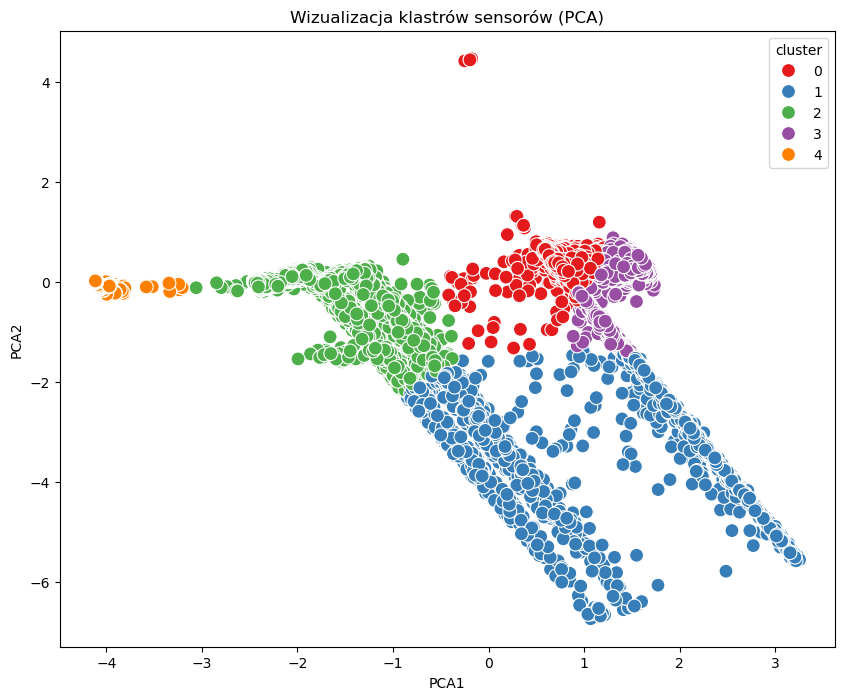

In [102]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
sensor_df_2D = pca.fit_transform(sensor_df_scaled)

sensor_df['PCA1'] = sensor_df_2D[:, 0]
sensor_df['PCA2'] = sensor_df_2D[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', data=sensor_df, palette='Set1', s=100)
plt.title('Wizualizacja klastrów sensorów (PCA)')
plt.show()